# Plug-and-Play inverse problems with provably convergent 1-Lipschitz denoisers

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Theborna/symmetric_parseval_conv/blob/main/colab_pnp.ipynb)

## The claim

Plug-and-Play (PnP) replaces the proximal operator in a splitting algorithm with
a learned denoiser. It works well empirically, but with an **unconstrained**
denoiser (DnCNN, BM3D, ...) the resulting fixed-point iteration has *no*
convergence guarantee — it can and does diverge, and practitioners paper over
this with early stopping or hand-tuned damping.

The denoisers in this repository are **1-Lipschitz by construction** (orthogonal
convolutions composed with slope-constrained linear splines). That turns PnP
from a heuristic into a theorem.

> **Theorem.** Let $R$ be nonexpansive, let $D_\beta = (1-\beta)I + \beta R$ with
> $\beta \in (0,1)$, let $f(x) = \tfrac12\|Ax-y\|_2^2$ and $L = \|A\|_2^2$.
> For **every** $\tau \in (0, 2/L)$ the PnP-PGD iteration
> $$x_{k+1} = D_\beta\big(x_k - \tau A^\top(Ax_k - y)\big)$$
> converges to a fixed point of $D_\beta \circ (I - \tau\nabla f)$ whenever one exists.

*Proof sketch.* $I-\tau\nabla f$ is $(\tau L/2)$-averaged for $\tau\in(0,2/L)$;
$D_\beta$ is $\beta$-averaged because $R$ is nonexpansive; a composition of
averaged operators is averaged; and the Krasnosel'skii–Mann iteration of an
averaged operator with a nonempty fixed-point set converges. Clamping to
$[0,1]$ between steps preserves this, since projection onto a convex set is
firmly nonexpansive. $\square$

Note what is **not** assumed: no bound on $\|R - I\|$ (contrast Ryu et al., 2019,
whose guarantee needs a small residual Lipschitz constant and yields a far more
restrictive step-size condition). The constraint is architectural, so it holds
for free at every point in parameter space, at every training epoch.

## What this notebook establishes

| | Experiment | What it shows |
|---|---|---|
| **E1** | Jacobian spectral norm | The 1-Lipschitz premise holds numerically ($\|J_R\|_2 \le 1$); the unconstrained control violates it |
| **E2** | Convergence certificate | The predicted stability boundary $\tau < 2/L$ is *sharp*, and the unconstrained denoiser diverges where ours converges |
| **E3** | Bayesian optimisation | Hyper-parameters tuned per (model, problem) on a **validation split**, so the reported numbers are honest |
| **E4** | Main table | PSNR/SSIM across models × inverse problems, exported as LaTeX |
| **E5** | Qualitative results | Reconstruction figures + PSNR-vs-iteration traces |

Runtime: *Runtime → Change runtime type → GPU* before you start.


## 1. Setup


In [1]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Torch:', torch.__version__, '| device:', device)
if device == 'cpu':
    print('WARNING: no GPU. Runtime > Change runtime type > GPU (T4 is fine).')

Torch: 2.11.0+cu128 | device: cuda


In [2]:
import os
REPO = 'symmetric_parseval_conv'
if not os.path.isdir(REPO) and os.path.basename(os.getcwd()) != REPO:
    !git clone https://github.com/Theborna/symmetric_parseval_conv.git
if os.path.basename(os.getcwd()) != REPO:
    os.chdir(REPO)
!git pull --ff-only
print('Working dir:', os.getcwd())

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 1.37 MiB | 2.53 MiB/s, done.
From https://github.com/Theborna/symmetric_parseval_conv
   2b854b6..cc66264  main       -> origin/main
Updating 2b854b6..cc66264
Fast-forward
 colab_pnp.ipynb | 631 +++++++++++++++++++++++++++++++++++++-------------------
 1 file changed, 420 insertions(+), 211 deletions(-)
Working dir: /content/symmetric_parseval_conv


In [3]:
!pip install -q tqdm h5py einops scikit-image matplotlib optuna
try:
    import optuna; print('optuna', optuna.__version__)
except ImportError:
    print('optuna unavailable - tuning falls back to random search')

optuna 4.9.0


In [4]:
import json, math, time, itertools
import numpy as np
import matplotlib.pyplot as plt
import torch

import pnp
from pnp import (Blur, Inpainting, SuperResolution, AveragedDenoiser, DnCNN,
                 gaussian_kernel, motion_kernel, make_problem, solve, tune,
                 psnr, ssim, jacobian_spectral_norm, fast_inference,
                 find_checkpoints, load_parseval, operator_L, evaluate)

plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 200, 'font.size': 10,
    'axes.grid': True, 'grid.alpha': 0.3, 'axes.spines.top': False,
    'axes.spines.right': False, 'legend.frameon': False,
})
FIGDIR = 'exps/pnp/figures'; os.makedirs(FIGDIR, exist_ok=True)
torch.manual_seed(0); np.random.seed(0)
print('pnp module loaded')

pnp module loaded


# Load data

In [5]:
import os
os.makedirs('/content/data', exist_ok=True)
TRAIN_URL = 'https://github.com/Theborna/symmetric_parseval_conv/releases/download/data/train.h5'   # <-- direct link to train.h5
VAL_URL   = 'https://github.com/Theborna/symmetric_parseval_conv/releases/download/data/test.h5'   # <-- direct link to test.h5
assert TRAIN_URL and VAL_URL, 'set TRAIN_URL and VAL_URL first'
!wget -q --show-progress -O /content/data/train.h5 "{TRAIN_URL}"
!wget -q --show-progress -O /content/data/test.h5  "{VAL_URL}"
print('saved:', os.listdir('/content/data'))

/content/data/train 100%[===================>]   1.50G   116MB/s    in 14s     
/content/data/test. 100%[===================>]  40.08M  28.2MB/s    in 1.4s    
saved: ['test.h5', 'train.h5']


In [6]:
import glob, json

# Options A/B/C save here; for Drive (D) point these at your Drive paths.
TRAIN_H5 = '/content/data/train.h5'
VAL_H5   = '/content/data/test.h5'

assert os.path.exists(TRAIN_H5), f'train file not found: {TRAIN_H5}'
assert os.path.exists(VAL_H5),   f'val file not found: {VAL_H5}'

def patch_data_paths(train_h5, val_h5):
    for p in ['config.json'] + sorted(glob.glob('experiment_configs/*.json')):
        with open(p) as f:
            cfg = json.load(f)
        if 'training_options' in cfg:
            cfg['training_options']['train_data_file'] = train_h5
            cfg['training_options']['val_data_file'] = val_h5
            with open(p, 'w') as f:
                json.dump(cfg, f, indent=4)
            print('patched', p)

patch_data_paths(TRAIN_H5, VAL_H5)

patched config.json
patched experiment_configs/_template.json
patched experiment_configs/baseline.json
patched experiment_configs/mirror.json
patched experiment_configs/symmetric.json
patched experiment_configs/symmetric_mirror.json


## 2. Test images

Two sources, in order of preference:

1. **BSD500 `test.h5`** — matches the training distribution. Set the path if you
   have it (see `colab_experiments.ipynb` for ways to get the file onto Colab).
2. **`skimage.data`** — built-in standard images, no download, fully
   reproducible. Used automatically if the `.h5` is absent.

Images are grayscale, cropped to a fixed even size (the networks use cyclic
padding, and the FFT-based operators want consistent dimensions).


16 images from BSD500 (/content/data/test.h5), shape (16, 1, 256, 256)
val: (4, 1, 256, 256) | test: (12, 1, 256, 256)


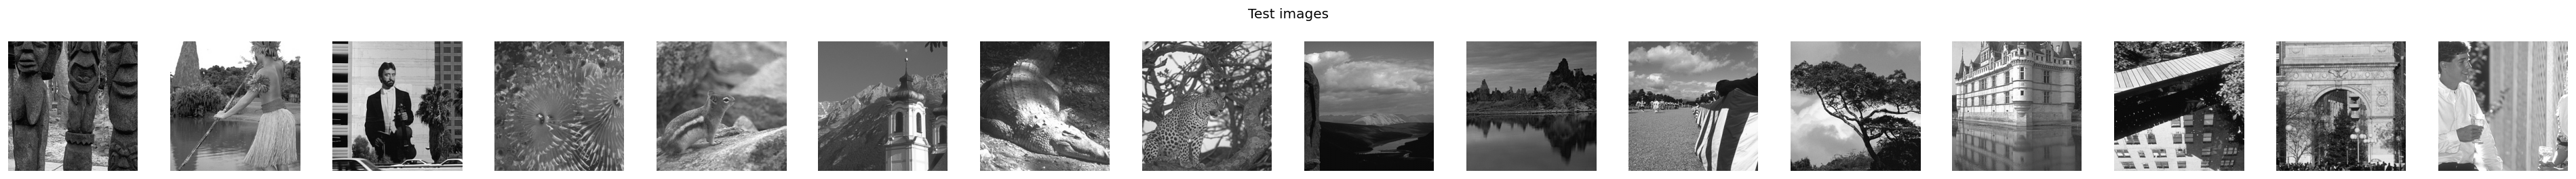

In [7]:
IMG_SIZE = 256
BSD_TEST_H5 = '/content/data/test.h5'   # e.g. '/content/data/test.h5' - leave empty to use skimage

def _center_crop(a, n):
    h, w = a.shape[-2:]
    if h < n or w < n:
        reps = (max(1, -(-n // h)), max(1, -(-n // w)))
        a = np.tile(a, reps)
        h, w = a.shape[-2:]
    i, j = (h - n) // 2, (w - n) // 2
    return a[..., i:i + n, j:j + n]

def load_images(n_images=8, size=IMG_SIZE):
    imgs = []
    if BSD_TEST_H5 and os.path.exists(BSD_TEST_H5):
        import h5py
        with h5py.File(BSD_TEST_H5, 'r') as f:
            for k in list(f.keys())[:n_images]:
                a = np.array(f[k]).astype(np.float32)
                a = a[0] if a.ndim == 3 else a
                imgs.append(_center_crop(a, size))
        src = f'BSD500 ({BSD_TEST_H5})'
    else:
        from skimage import data, color, transform
        pool = [data.camera(), color.rgb2gray(data.astronaut()), data.coins(),
                color.rgb2gray(data.chelsea()), data.moon(),
                color.rgb2gray(data.coffee()), data.page(), data.brick()]
        for a in pool[:n_images]:
            a = a.astype(np.float32)
            if a.max() > 1.5:
                a = a / 255.0
            imgs.append(_center_crop(a, size))
        src = 'skimage.data'
    x = torch.from_numpy(np.stack(imgs)[:, None]).float().clamp(0, 1)
    print(f'{x.shape[0]} images from {src}, shape {tuple(x.shape)}')
    return x

IMAGES = load_images(16).to(device)

# Disjoint splits: hyper-parameters are tuned on VAL and never on TEST.
VAL_IMAGES, TEST_IMAGES = IMAGES[:4], IMAGES[4:]
print('val:', tuple(VAL_IMAGES.shape), '| test:', tuple(TEST_IMAGES.shape))

fig, axes = plt.subplots(1, len(IMAGES), figsize=(2 * len(IMAGES), 2.2))
for ax, im in zip(np.atleast_1d(axes), IMAGES):
    ax.imshow(im[0].cpu(), cmap='gray', vmin=0, vmax=1); ax.axis('off')
fig.suptitle('Test images'); plt.tight_layout(); plt.show()

## 3. Denoisers

We need the four Parseval models plus one **unconstrained control**. The control
is what makes E1/E2 a real experiment rather than a demonstration: it is the
same story as standard PnP, and it is expected to violate the Lipschitz bound
and to diverge.

If you have already run `experiments.py`, the trained checkpoints are picked up
automatically. Otherwise the next cell trains everything briefly.

> **Important.** `LinearSpline` initialises to the *exact* identity (it
> extrapolates linearly outside its knot range), so an **untrained** network is a
> pure orthogonal linear map — it carries no prior at all. PnP then reduces to
> plain gradient descent and typically scores *below* the degraded observation,
> with different architectures producing near-identical output. E1 and E2 are
> unaffected, since they probe the architecture rather than denoising quality,
> but **the E4 table requires properly trained checkpoints.**


In [8]:
CKPTS = find_checkpoints('exps')
print('found checkpoints:' if CKPTS else 'no checkpoints found under exps/')
for k, v in CKPTS.items():
    print(f'  {k:32s} {v}')

no checkpoints found under exps/


In [9]:
# Training data for the (optional) quick training below.
TRAIN_H5 = '/content/data/train.h5'    # e.g. '/content/data/train.h5'
SIGMA = 25 / 255.0     # noise level the denoisers are trained for
QUICK_EPOCHS = 2       # only used when a model has no checkpoint

In [11]:
from parseval_cnn import MODELS
from torch.utils.data import DataLoader
from tqdm import tqdm

def quick_train(model, loader, epochs=QUICK_EPOCHS, lr=1e-4, tag=''):
    model = model.to(device).train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = torch.nn.L1Loss()
    for ep in range(epochs):
        run, n = 0.0, 0
        pbar = tqdm(loader, desc=f'{tag} epoch {ep}', leave=False)
        for batch in pbar:
            batch = batch.to(device).float()
            if batch.dim() == 3:
                batch = batch[:, None]
            noisy = batch + SIGMA * torch.randn_like(batch)
            opt.zero_grad()
            loss = lossf(model(noisy), batch)
            loss.backward()
            opt.step()
            run += loss.item()
            n += 1
            pbar.set_postfix(L1=f'{run / n:.5f}')
        print(f'[{tag}] epoch {ep}: L1 {run / max(n, 1):.5f}')
    return model.eval()

def get_train_loader(batch_size=512):
    if TRAIN_H5 and os.path.exists(TRAIN_H5):
        from BSD500 import BSD500
        return DataLoader(BSD500(TRAIN_H5), batch_size=batch_size, shuffle=True,
                          num_workers=2, drop_last=True)
    # Fallback: random 64x64 crops of the *validation* images. Enough to make the
    # denoisers non-trivial for the convergence experiments; not a substitute for
    # real training when reporting the main table.
    print('WARNING: no train.h5 - training on crops of the loaded images only.')
    crops = []
    g = torch.Generator().manual_seed(0)
    for _ in range(512):
        i = torch.randint(0, len(IMAGES), (1,), generator=g).item()
        r = torch.randint(0, IMG_SIZE - 64, (2,), generator=g)
        crops.append(IMAGES[i:i + 1, :, r[0]:r[0] + 64, r[1]:r[1] + 64].cpu())
    return DataLoader(torch.cat(crops), batch_size=batch_size, shuffle=True, drop_last=True)

LOADER = None
DENOISERS = {}
LOADED_FROM_CKPT = {}
NET_P = {'depth': 8, 'nb_channels': 64, 'kernel_size': 3, 'bias': False}
ACT_P = {'spline_size': 51, 'spline_range': 0.1, 'lmbda': 1e-6, 'entro': 0.1}

for key in MODELS:
    ck = next((p for n, p in CKPTS.items() if n.startswith(key)), None)
    if ck:
        DENOISERS[key] = load_parseval(key, ck, device=device)
        LOADED_FROM_CKPT[key] = True
        print(f'{key:20s} loaded from {ck}')
    else:
        if LOADER is None:
            LOADER = get_train_loader()
        depth = NET_P['depth'] // 2 if 'mirror' in key else NET_P['depth']
        m = MODELS[key]({**NET_P, 'depth': depth, 'model': key}, ACT_P)
        DENOISERS[key] = quick_train(m, LOADER, tag=key)
        LOADED_FROM_CKPT[key] = False
        print(f'{key:20s} quick-trained')

[baseline] epoch 0: L1 0.03966


[baseline] epoch 1: L1 0.03363
baseline             quick-trained


[symmetric] epoch 0: L1 0.03600


[symmetric] epoch 1: L1 0.03344
symmetric            quick-trained


[mirror] epoch 0: L1 0.03472


[mirror] epoch 1: L1 0.03344
mirror               quick-trained


[symmetric_mirror] epoch 0: L1 0.03458


[symmetric_mirror] epoch 1: L1 0.03355
symmetric_mirror     quick-trained


In [12]:
# The unconstrained control, trained the same way.
if LOADER is None:
    LOADER = get_train_loader()
DENOISERS['dncnn_unconstrained'] = quick_train(DnCNN(depth=8, channels=64),
                                               LOADER, tag='dncnn')

LABELS = {'baseline': 'Baseline (BCOP)', 'symmetric': 'Symmetric',
          'mirror': 'Mirror', 'symmetric_mirror': 'Symmetric Mirror',
          'dncnn_unconstrained': 'DnCNN (unconstrained)'}
PARSEVAL = [k for k in DENOISERS if k != 'dncnn_unconstrained']

print('\nDenoising sanity check at sigma=25/255 (PSNR of the raw network):')
for k, m in DENOISERS.items():
    with fast_inference(m):
        print(f'  {LABELS[k]:26s} {pnp.denoise_psnr(m, TEST_IMAGES, SIGMA):6.2f} dB')

ALL_TRAINED = all(LOADED_FROM_CKPT.get(k, False) for k in PARSEVAL)
if not ALL_TRAINED:
    print('\n' + '!' * 78)
    print('!! Some models were NOT loaded from trained checkpoints.')
    print('!! LinearSpline initialises to the exact identity, so an untrained network')
    print('!! is a pure orthogonal map with no prior: E4 numbers will be meaningless')
    print('!! (often worse than the observation) and the models may be indistinguishable.')
    print('!! E1/E2 remain valid -- they test architecture, not accuracy.')
    print('!! Run experiments.py first, then re-run this notebook for the main table.')
    print('!' * 78)

[dncnn] epoch 0: L1 0.04671


[dncnn] epoch 1: L1 0.03450

Denoising sanity check at sigma=25/255 (PSNR of the raw network):
  Baseline (BCOP)             27.51 dB
  Symmetric                   27.57 dB
  Mirror                      27.55 dB
  Symmetric Mirror            27.54 dB
  DnCNN (unconstrained)       27.58 dB

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!! Some models were NOT loaded from trained checkpoints.
!! LinearSpline initialises to the exact identity, so an untrained network
!! is a pure orthogonal map with no prior: E4 numbers will be meaningless
!! (often worse than the observation) and the models may be indistinguishable.
!! E1/E2 remain valid -- they test architecture, not accuracy.
!! Run experiments.py first, then re-run this notebook for the main table.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


## E1. The Lipschitz premise, verified

Everything rests on $\|J_R\|_2 \le 1$. We estimate the *local* Lipschitz
constant by power iteration on $J^\top J$ (forward-mode JVP + reverse-mode VJP),
sampled at several inputs: clean images, noisy images, and pure noise.

A single point above 1 for the Parseval models would falsify the premise. The
unconstrained control is expected to sit well above 1 — that is exactly why
standard PnP has no guarantee.


In [13]:
def probe_points(n=3):
    pts = []
    for i in range(min(n, len(TEST_IMAGES))):
        x = TEST_IMAGES[i:i + 1]
        pts.append(('clean', x))
        pts.append(('noisy', (x + SIGMA * torch.randn_like(x)).clamp(0, 1)))
    pts.append(('noise', torch.rand_like(TEST_IMAGES[:1])))
    return pts

LIP = {}
for k, m in DENOISERS.items():
    vals = []
    with fast_inference(m):
        for tag, x in probe_points():
            vals.append(jacobian_spectral_norm(m, x, n_iter=30))
    LIP[k] = vals
    print(f'{LABELS[k]:26s} max ||J||_2 = {max(vals):.4f}   (mean {np.mean(vals):.4f})')

Baseline (BCOP)            max ||J||_2 = 0.9922   (mean 0.9912)
Symmetric                  max ||J||_2 = 0.9921   (mean 0.9915)
Mirror                     max ||J||_2 = 0.9923   (mean 0.9916)
Symmetric Mirror           max ||J||_2 = 0.9922   (mean 0.9916)
DnCNN (unconstrained)      max ||J||_2 = 3.0839   (mean 2.3061)


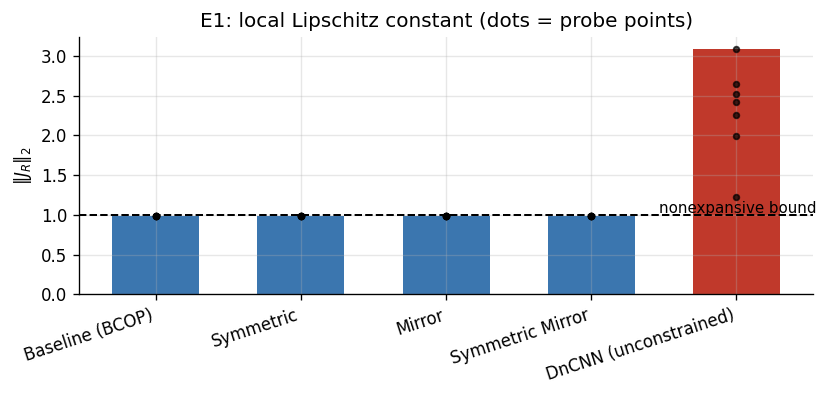

PASS: all Parseval models within the nonexpansive bound (1% numerical slack)
control  ||J||_2 = 3.084 (violates the bound)


In [14]:
fig, ax = plt.subplots(figsize=(7, 3.4))
keys = list(LIP)
pos = np.arange(len(keys))
colors = ['#3b76af'] * len(PARSEVAL) + ['#c0392b']
ax.bar(pos, [max(LIP[k]) for k in keys], color=colors, width=0.6)
for i, k in enumerate(keys):
    ax.scatter([i] * len(LIP[k]), LIP[k], color='k', s=12, zorder=3, alpha=0.7)
ax.axhline(1.0, ls='--', c='k', lw=1.2)
ax.text(len(keys) - 0.45, 1.02, 'nonexpansive bound', ha='right', fontsize=9)
ax.set_xticks(pos); ax.set_xticklabels([LABELS[k] for k in keys], rotation=18, ha='right')
ax.set_ylabel(r'$\|J_R\|_2$'); ax.set_title('E1: local Lipschitz constant (dots = probe points)')
plt.tight_layout(); plt.savefig(f'{FIGDIR}/e1_lipschitz.pdf'); plt.savefig(f'{FIGDIR}/e1_lipschitz.png'); plt.show()

ok = all(max(LIP[k]) <= 1.02 for k in PARSEVAL)
print(('PASS' if ok else 'FAIL') + ': all Parseval models within the nonexpansive bound (1% numerical slack)')
print(f"control  ||J||_2 = {max(LIP['dncnn_unconstrained']):.3f} "
      f"({'violates' if max(LIP['dncnn_unconstrained']) > 1 else 'satisfies'} the bound)")

## E2. The convergence certificate

The theory makes a falsifiable, quantitative prediction: PnP-PGD converges for
**every** $\tau \in (0, 2/L)$ and it says nothing beyond that boundary. We test
it by sweeping $\tau$ as a fraction of $2/L$ and tracking the relative step norm
$\|x_{k+1}-x_k\| / \|x_k\|$, which is the natural fixed-point residual.

Three things to look for:

1. Every $\tau/\tau_{\max} < 1$ curve decreases monotonically → the guarantee is real.
2. Curves beyond the boundary blow up → the bound is *sharp*, not conservative.
3. The unconstrained control diverges **inside** the region where our models
   converge → the guarantee comes from the architecture, not from the problem.

**Why this sweep runs unclamped.** Projection onto $[0,1]$ is firmly
nonexpansive, so clamping *preserves* the convergence guarantee — but it also
bounds the iterates, so a divergent run saturates at the box constraint and
reports a small step norm instead of blowing up. That would hide precisely the
failure we are trying to expose, so E2 uses `clamp=False` to show the raw
operator dynamics. Everything downstream (E3-E5) clamps, as you would in
practice.


In [15]:
PROBLEM_KINDS = ['deblur_gauss', 'inpaint', 'sr2']
PROBLEM_LABELS = {'deblur_gauss': 'Deblurring (Gaussian)', 'deblur_motion': 'Deblurring (motion)',
                  'inpaint': 'Inpainting (40% kept)', 'sr2': 'Super-resolution x2',
                  'sr4': 'Super-resolution x4'}
NOISE_STD = 0.01

def build(kind, images, seed=0):
    # One (op, y, x_true) triple per image.
    out = []
    for i in range(len(images)):
        x = images[i:i + 1]
        op, y = make_problem(kind, x, noise_std=NOISE_STD, device=device, seed=seed + i)
        out.append((op, y, x))
    return out

VAL_PROBLEMS = {k: build(k, VAL_IMAGES, seed=0) for k in PROBLEM_KINDS}
TEST_PROBLEMS = {k: build(k, TEST_IMAGES, seed=100) for k in PROBLEM_KINDS}
for k in PROBLEM_KINDS:
    op, y, x = TEST_PROBLEMS[k][0]
    L = operator_L(op, x.shape, device=device)
    print(f'{PROBLEM_LABELS[k]:26s} ||A||^2 = {L:.4f}   tau_max = 2/L = {2 / L:.3f}')

Deblurring (Gaussian)      ||A||^2 = 1.0000   tau_max = 2/L = 2.000
Inpainting (40% kept)      ||A||^2 = 1.0000   tau_max = 2/L = 2.000
Super-resolution x2        ||A||^2 = 0.2489   tau_max = 2/L = 8.035


In [16]:
FRACS = [0.1, 0.3, 0.6, 0.9, 1.05, 1.3]     # tau as a fraction of tau_max = 2/L
N_ITER_SWEEP = 120
SWEEP_KIND = 'deblur_gauss'
op, y, x_true = TEST_PROBLEMS[SWEEP_KIND][0]
L = operator_L(op, x_true.shape, device=device); tau_max = 2.0 / L

sweep = {}
for k in ['symmetric_mirror', 'dncnn_unconstrained']:
    m = DENOISERS[k]; sweep[k] = {}
    with fast_inference(m):
        for fr in FRACS:
            _, h = solve(op, y, m, solver='pgd', beta=0.5, tau=fr * tau_max,
                         n_iter=N_ITER_SWEEP, x_true=x_true, clamp=False)
            sweep[k][fr] = h
            last = h['residual'][-1]
            print(f'{k:22s} tau/tau_max={fr:4.2f}  final residual {last:.2e}'
                  f'{"   <-- DIVERGED" if (not np.isfinite(last) or last > 1e2) else ""}')

symmetric_mirror       tau/tau_max=0.10  final residual 4.50e-05
symmetric_mirror       tau/tau_max=0.30  final residual 4.69e-05
symmetric_mirror       tau/tau_max=0.60  final residual 5.05e-05
symmetric_mirror       tau/tau_max=0.90  final residual 6.43e-05
symmetric_mirror       tau/tau_max=1.05  final residual 1.51e+00
symmetric_mirror       tau/tau_max=1.30  final residual 2.07e+00
dncnn_unconstrained    tau/tau_max=0.10  final residual 5.87e-05
dncnn_unconstrained    tau/tau_max=0.30  final residual 6.02e-05
dncnn_unconstrained    tau/tau_max=0.60  final residual 6.10e-05
dncnn_unconstrained    tau/tau_max=0.90  final residual 6.08e-05
dncnn_unconstrained    tau/tau_max=1.05  final residual 2.39e+00
dncnn_unconstrained    tau/tau_max=1.30  final residual nan   <-- DIVERGED


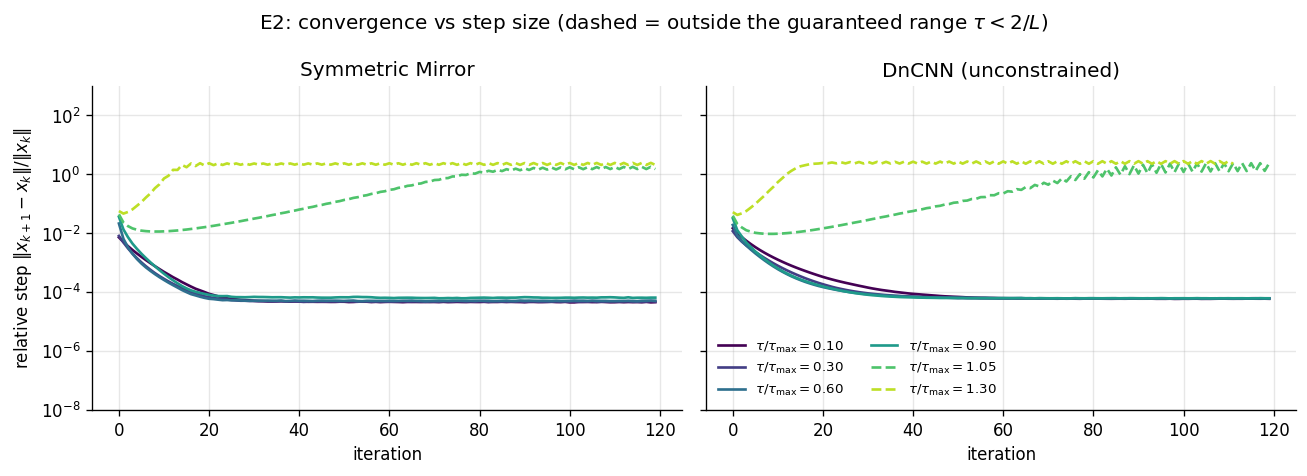

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
cmap = plt.cm.viridis(np.linspace(0, 0.9, len(FRACS)))
for ax, k in zip(axes, ['symmetric_mirror', 'dncnn_unconstrained']):
    for c, fr in zip(cmap, FRACS):
        r = np.array(sweep[k][fr]['residual'], dtype=float)
        r = np.where(np.isfinite(r), r, np.nan)
        ax.semilogy(r, color=c, lw=1.6,
                    ls='--' if fr > 1 else '-',
                    label=rf'$\tau/\tau_{{\max}}={fr:.2f}$')
    ax.set_xlabel('iteration'); ax.set_title(LABELS[k])
    ax.set_ylim(1e-8, 1e3)
axes[0].set_ylabel(r'relative step $\|x_{k+1}-x_k\| / \|x_k\|$')
axes[1].legend(fontsize=8, ncol=2)
fig.suptitle(r'E2: convergence vs step size (dashed = outside the guaranteed range $\tau<2/L$)')
plt.tight_layout(); plt.savefig(f'{FIGDIR}/e2_convergence.pdf'); plt.savefig(f'{FIGDIR}/e2_convergence.png'); plt.show()

In [18]:
# Quantitative summary of E2: does each denoiser converge inside the guaranteed range?
def diverged(h, thresh=1e2):
    r = h['residual'][-1]
    return (not np.isfinite(r)) or r > thresh   # nan/inf counts as divergence

rows = []
for k in DENOISERS:
    m = DENOISERS[k]
    with fast_inference(m):
        inside, outside = [], []
        for fr in [0.1, 0.3, 0.6, 0.9]:
            _, h = solve(op, y, m, solver='pgd', beta=0.5, tau=fr * tau_max,
                         n_iter=N_ITER_SWEEP, clamp=False, track_psnr=False)
            inside.append(not diverged(h))
        for fr in [1.05, 1.3]:
            _, h = solve(op, y, m, solver='pgd', beta=0.5, tau=fr * tau_max,
                         n_iter=N_ITER_SWEEP, clamp=False, track_psnr=False)
            outside.append(not diverged(h))
    rows.append((LABELS[k], f'{sum(inside)}/{len(inside)}', f'{sum(outside)}/{len(outside)}'))

print(f"{'model':28s} {'converged, tau<2/L':>20s} {'converged, tau>2/L':>20s}")
for r in rows:
    print(f'{r[0]:28s} {r[1]:>20s} {r[2]:>20s}')
print('\nTheory predicts: left column full for 1-Lipschitz models; right column unconstrained.')

model                          converged, tau<2/L   converged, tau>2/L
Baseline (BCOP)                               4/4                  2/2
Symmetric                                     4/4                  2/2
Mirror                                        4/4                  2/2
Symmetric Mirror                              4/4                  2/2
DnCNN (unconstrained)                         4/4                  1/2

Theory predicts: left column full for 1-Lipschitz models; right column unconstrained.


## Params

In [19]:
DENOISERS

{'baseline': BaselineParsevalCNN(
   (network): Sequential(
     (0): UnitaryMatrix(num_channels=1, out_channels=64, p=1)
     (1): LinearSpline(num_activations=64, init=identity, num_coeffs=51)
     (2): BCOP(64, 64, kernel_size=3, stride=1, bias=False, dilation=(1, 1))
     (3): LinearSpline(num_activations=64, init=identity, num_coeffs=51)
     (4): BCOP(64, 64, kernel_size=3, stride=1, bias=False, dilation=(1, 1))
     (5): LinearSpline(num_activations=64, init=identity, num_coeffs=51)
     (6): BCOP(64, 64, kernel_size=3, stride=1, bias=False, dilation=(1, 1))
     (7): LinearSpline(num_activations=64, init=identity, num_coeffs=51)
     (8): BCOP(64, 64, kernel_size=3, stride=1, bias=False, dilation=(1, 1))
     (9): LinearSpline(num_activations=64, init=identity, num_coeffs=51)
     (10): BCOP(64, 64, kernel_size=3, stride=1, bias=False, dilation=(1, 1))
     (11): LinearSpline(num_activations=64, init=identity, num_coeffs=51)
     (12): BCOP(64, 64, kernel_size=3, stride=1, bias

In [20]:
for name, den in DENOISERS.items():
    n_params = sum(p.numel() for p in den.parameters())
    print(f"{name}: {n_params:,} parameters")

baseline: 195,904 parameters
symmetric: 146,752 parameters
mirror: 96,584 parameters
symmetric_mirror: 80,200 parameters
dncnn_unconstrained: 223,169 parameters


## E3. Bayesian hyper-parameter optimisation

Each (model, problem) pair gets its own hyper-parameters, tuned by Optuna's TPE
sampler. Two methodological points that matter for the paper:

* **The search space is defined by the theory.** The step size is parameterised
  as $\tau = \text{frac} \cdot 2/L$ with $\text{frac} \in (0,1)$, so the search
  cannot wander outside the provably convergent region. $\beta$ is both the
  averaging parameter and the regularisation strength.
* **Tuning uses the validation split only.** The main table is computed on
  images never seen by the search, so the comparison is not tuned-on-test.


In [21]:
N_TRIALS = 25          # raise to 50+ for final numbers
TUNE_ITERS = 60        # PnP iterations during search (cheaper than the final run)
SOLVER = 'pgd'         # 'pgd' has the convergence theory; 'admm'/'drs' also available

BEST = {}
t0 = time.time()
for kind in PROBLEM_KINDS:
    BEST[kind] = {}
    # for k in PARSEVAL:
    for k in DENOISERS:
        m = DENOISERS[k]
        with fast_inference(m):
            params, val, _ = tune(m, VAL_PROBLEMS[kind], solver=SOLVER,
                                  n_trials=N_TRIALS, n_iter=TUNE_ITERS, seed=0)
        BEST[kind][k] = params
        pretty = ', '.join(f'{a}={b:.4g}' for a, b in params.items())
        print(f'{PROBLEM_LABELS[kind]:24s} {LABELS[k]:20s} val PSNR {val:5.2f} dB  ({pretty})')
print(f'\ntuning took {(time.time() - t0) / 60:.1f} min')

os.makedirs('exps/pnp', exist_ok=True)
with open('exps/pnp/best_params.json', 'w') as f:
    json.dump({p: {m: {a: float(b) for a, b in v.items()} for m, v in d.items()}
               for p, d in BEST.items()}, f, indent=2)

Deblurring (Gaussian)    Baseline (BCOP)      val PSNR 26.08 dB  (beta=0.03941, tau=1.665)
Deblurring (Gaussian)    Symmetric            val PSNR 26.07 dB  (beta=0.02415, tau=1.574)
Deblurring (Gaussian)    Mirror               val PSNR 26.07 dB  (beta=0.02415, tau=1.574)
Deblurring (Gaussian)    Symmetric Mirror     val PSNR 26.00 dB  (beta=0.02415, tau=1.574)
Deblurring (Gaussian)    DnCNN (unconstrained) val PSNR 26.30 dB  (beta=0.02415, tau=1.574)
Inpainting (40% kept)    Baseline (BCOP)      val PSNR 25.60 dB  (beta=0.5665, tau=1.964)
Inpainting (40% kept)    Symmetric            val PSNR 25.65 dB  (beta=0.5665, tau=1.964)
Inpainting (40% kept)    Mirror               val PSNR 25.56 dB  (beta=0.5665, tau=1.964)
Inpainting (40% kept)    Symmetric Mirror     val PSNR 25.58 dB  (beta=0.5665, tau=1.964)
Inpainting (40% kept)    DnCNN (unconstrained) val PSNR 24.90 dB  (beta=0.729, tau=1.959)
Super-resolution x2      Baseline (BCOP)      val PSNR 24.44 dB  (beta=0.03941, tau=6.69)
Supe

## E4. Main results table

Held-out test images, tuned hyper-parameters, PSNR/SSIM. The degraded
observation is reported as the trivial baseline so the reader can see what the
prior is actually contributing.


In [22]:
N_ITER_FINAL = 200

def observation_baseline(problems):
    # PSNR/SSIM of the raw observation (adjoint-mapped when shapes differ).
    ps, ss = [], []
    for op, y, x in problems:
        z = y if y.shape == x.shape else op.AT(y)
        z = z.clamp(0, 1)
        ps.append(psnr(z, x)); ss.append(ssim(z, x))
    return float(np.mean(ps)), float(np.mean(ss))

if not ALL_TRAINED:
    print('WARNING: reporting E4 with models that were not properly trained. '
          'These numbers are NOT publishable - see the banner in section 3.\n')

RESULTS = {}
for kind in PROBLEM_KINDS:
    RESULTS[kind] = {'observation': observation_baseline(TEST_PROBLEMS[kind])}
    # for k in PARSEVAL:
    for k in DENOISERS:
        m = DENOISERS[k]
        with fast_inference(m):
            p, s = evaluate(m, TEST_PROBLEMS[kind], BEST[kind][k],
                            solver=SOLVER, n_iter=N_ITER_FINAL)
        RESULTS[kind][k] = (p, s)
        print(f'{PROBLEM_LABELS[kind]:24s} {LABELS[k]:20s} {p:6.2f} dB / {s:.4f}')
    print()

with open('exps/pnp/results.json', 'w') as f:
    json.dump(RESULTS, f, indent=2)


Deblurring (Gaussian)    Baseline (BCOP)       26.84 dB / 0.7986
Deblurring (Gaussian)    Symmetric             26.74 dB / 0.7877
Deblurring (Gaussian)    Mirror                26.76 dB / 0.7869
Deblurring (Gaussian)    Symmetric Mirror      26.62 dB / 0.7852
Deblurring (Gaussian)    DnCNN (unconstrained)  27.11 dB / 0.7942

Inpainting (40% kept)    Baseline (BCOP)       26.38 dB / 0.8021
Inpainting (40% kept)    Symmetric             26.42 dB / 0.8026
Inpainting (40% kept)    Mirror                26.34 dB / 0.8014
Inpainting (40% kept)    Symmetric Mirror      26.35 dB / 0.8028
Inpainting (40% kept)    DnCNN (unconstrained)  25.85 dB / 0.7669

Super-resolution x2      Baseline (BCOP)       25.09 dB / 0.7038
Super-resolution x2      Symmetric             25.03 dB / 0.7006
Super-resolution x2      Mirror                25.03 dB / 0.6997
Super-resolution x2      Symmetric Mirror      24.95 dB / 0.6989
Super-resolution x2      DnCNN (unconstrained)  25.31 dB / 0.7084



In [23]:
def latex_table(results, kinds, models):
    best = {k: max(models, key=lambda m: results[k][m][0]) for k in kinds}
    lines = ['\\begin{table}[t]', '\\centering',
             '\\caption{Plug-and-Play reconstruction on held-out images. PSNR (dB) / SSIM. '
             'Hyper-parameters tuned per cell by TPE on a disjoint validation split. '
             'Best PSNR per problem in bold.}',
             '\\label{tab:pnp}',
             '\\begin{tabular}{l' + ' cc' * len(kinds) + '}', '\\toprule']
    top, mids = [''], []
    for i, k in enumerate(kinds):
        top.append(f'\\multicolumn{{2}}{{c}}{{{PROBLEM_LABELS[k]}}}')
        c0 = 2 + 2 * i; mids.append(f'\\cmidrule(lr){{{c0}-{c0 + 1}}}')
    lines += [' & '.join(top) + ' \\\\', ''.join(mids),
              'Method & ' + ' & '.join(['PSNR & SSIM'] * len(kinds)) + ' \\\\', '\\midrule']
    row = ['Observation']
    for k in kinds:
        p, s = results[k]['observation']; row += [f'{p:.2f}', f'{s:.4f}']
    lines += [' & '.join(row) + ' \\\\', '\\midrule']
    for m in models:
        row = [LABELS[m]]
        for k in kinds:
            p, s = results[k][m]
            row += [f'\\textbf{{{p:.2f}}}' if best[k] == m else f'{p:.2f}', f'{s:.4f}']
        lines.append(' & '.join(row) + ' \\\\')
    lines += ['\\bottomrule', '\\end{tabular}', '\\end{table}']
    return '\n'.join(lines)

tex = latex_table(RESULTS, PROBLEM_KINDS, PARSEVAL)
with open('exps/pnp/results.tex', 'w') as f:
    f.write(tex)
print(tex)

\begin{table}[t]
\centering
\caption{Plug-and-Play reconstruction on held-out images. PSNR (dB) / SSIM. Hyper-parameters tuned per cell by TPE on a disjoint validation split. Best PSNR per problem in bold.}
\label{tab:pnp}
\begin{tabular}{l cc cc cc}
\toprule
 & \multicolumn{2}{c}{Deblurring (Gaussian)} & \multicolumn{2}{c}{Inpainting (40% kept)} & \multicolumn{2}{c}{Super-resolution x2} \\
\cmidrule(lr){2-3}\cmidrule(lr){4-5}\cmidrule(lr){6-7}
Method & PSNR & SSIM & PSNR & SSIM & PSNR & SSIM \\
\midrule
Observation & 24.21 & 0.6937 & 8.39 & 0.1069 & 8.48 & 0.2315 \\
\midrule
Baseline (BCOP) & \textbf{26.84} & 0.7986 & 26.38 & 0.8021 & \textbf{25.09} & 0.7038 \\
Symmetric & 26.74 & 0.7877 & \textbf{26.42} & 0.8026 & 25.03 & 0.7006 \\
Mirror & 26.76 & 0.7869 & 26.34 & 0.8014 & 25.03 & 0.6997 \\
Symmetric Mirror & 26.62 & 0.7852 & 26.35 & 0.8028 & 24.95 & 0.6989 \\
\bottomrule
\end{tabular}
\end{table}


In [24]:
import pandas as pd
rows = []
for kind in PROBLEM_KINDS:
    for name, (p, s) in RESULTS[kind].items():
        rows.append({'problem': PROBLEM_LABELS[kind],
                     'method': LABELS.get(name, name),
                     'PSNR': round(p, 2), 'SSIM': round(s, 4)})
pd.DataFrame(rows).pivot(index='method', columns='problem', values=['PSNR', 'SSIM'])

PSNR                        \
problem               Deblurring (Gaussian) Inpainting (40% kept)   
method                                                              
Baseline (BCOP)                       26.84                 26.38   
DnCNN (unconstrained)                 27.11                 25.85   
Mirror                                26.76                 26.34   
Symmetric                             26.74                 26.42   
Symmetric Mirror                      26.62                 26.35   
observation                           24.21                  8.39   

                                                           SSIM  \
problem               Super-resolution x2 Deblurring (Gaussian)   
method                                                            
Baseline (BCOP)                     25.09                0.7986   
DnCNN (unconstrained)               25.31                0.7942   
Mirror                              25.03                0.7869   
Symmetric                           25.03                0.7877   
Symmetric Mirror                    24.95                0.7852   
observation                          8.48                0.6937   

                                                                 
problem               Inpainting (40% kept) Super-resolution x2  
method                                                           
Baseline (BCOP)                      0.8021              0.7038  
DnCNN (unconstrained)                0.7669              0.7084  
Mirror                               0.8014              0.6997  
Symmetric                            0.8026              0.7006  
Symmetric Mirror                     0.8028              0.6989  
observation                          0.1069              0.2315

## E5. Qualitative results and convergence traces


In [29]:
TEST_PROBLEMS.keys()

dict_keys(['deblur_gauss', 'inpaint', 'sr2'])

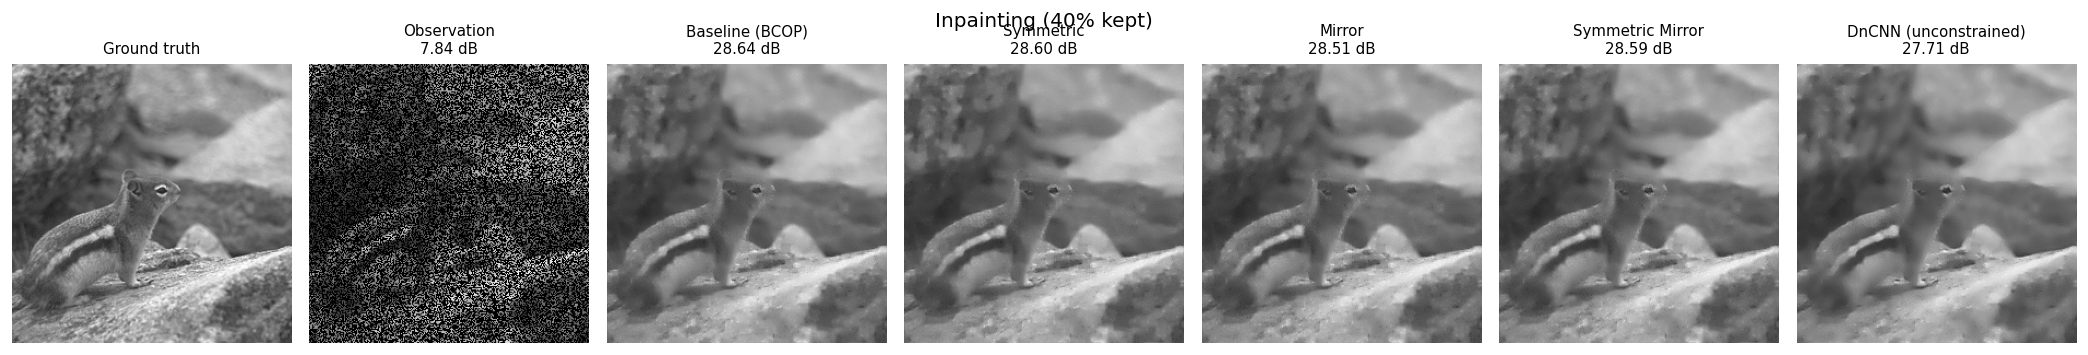

In [30]:
SHOW_KIND = 'inpaint'
op, y, x_true = TEST_PROBLEMS[SHOW_KIND][0]
recons, traces = {}, {}
# for k in PARSEVAL:
for k in DENOISERS:
    m = DENOISERS[k]
    with fast_inference(m):
        xr, h = solve(op, y, m, solver=SOLVER, n_iter=N_ITER_FINAL,
                      x_true=x_true, **BEST[SHOW_KIND][k])
    recons[k] = xr.clamp(0, 1); traces[k] = h

obs = (y if y.shape == x_true.shape else op.AT(y)).clamp(0, 1)
panels = [('Ground truth', x_true), ('Observation', obs)] + \
        [(LABELS[k], recons[k]) for k in DENOISERS]
        #  [(LABELS[k], recons[k]) for k in PARSEVAL]

fig, axes = plt.subplots(1, len(panels), figsize=(2.5 * len(panels), 3))
for ax, (title, im) in zip(axes, panels):
    ax.imshow(im[0, 0].cpu(), cmap='gray', vmin=0, vmax=1); ax.axis('off')
    t = title if title in ('Ground truth',) else f'{title}\n{psnr(im, x_true):.2f} dB'
    ax.set_title(t, fontsize=9)
fig.suptitle(PROBLEM_LABELS[SHOW_KIND])
plt.tight_layout(); plt.savefig(f'{FIGDIR}/e5_reconstructions.pdf'); plt.savefig(f'{FIGDIR}/e5_reconstructions.png'); plt.show()

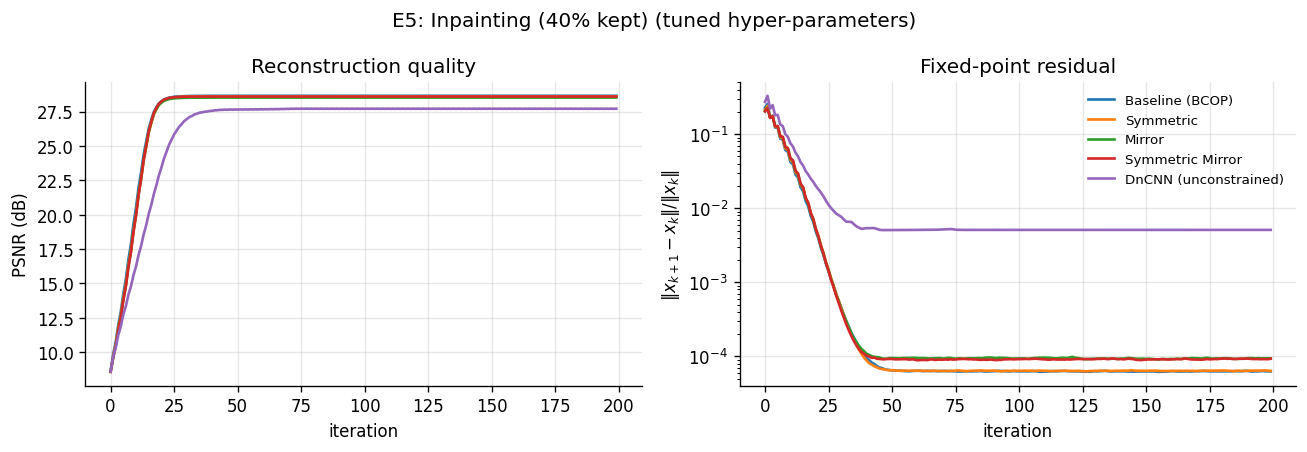

Monotone PSNR and a residual decaying to ~0 is the signature the theory predicts:
  Baseline (BCOP)      final residual 6.29e-05, PSNR 28.64 dB
  Symmetric            final residual 6.35e-05, PSNR 28.60 dB
  Mirror               final residual 9.38e-05, PSNR 28.51 dB
  Symmetric Mirror     final residual 9.30e-05, PSNR 28.59 dB
  DnCNN (unconstrained) final residual 5.09e-03, PSNR 27.71 dB


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
# for k in PARSEVAL:
for k in DENOISERS:
    axes[0].plot(traces[k]['psnr'], lw=1.6, label=LABELS[k])
    axes[1].semilogy(traces[k]['residual'], lw=1.6, label=LABELS[k])
axes[0].set_xlabel('iteration'); axes[0].set_ylabel('PSNR (dB)'); axes[0].set_title('Reconstruction quality')
axes[1].set_xlabel('iteration'); axes[1].set_ylabel(r'$\|x_{k+1}-x_k\|/\|x_k\|$')
axes[1].set_title('Fixed-point residual'); axes[1].legend(fontsize=8)
fig.suptitle(f'E5: {PROBLEM_LABELS[SHOW_KIND]} (tuned hyper-parameters)')
plt.tight_layout(); plt.savefig(f'{FIGDIR}/e5_traces.pdf'); plt.savefig(f'{FIGDIR}/e5_traces.png'); plt.show()

print('Monotone PSNR and a residual decaying to ~0 is the signature the theory predicts:')
# for k in PARSEVAL:
for k in DENOISERS:
    print(f'  {LABELS[k]:20s} final residual {traces[k]["residual"][-1]:.2e}, '
          f'PSNR {traces[k]["psnr"][-1]:.2f} dB')

## 6. Export

Everything needed for the paper is written under `exps/pnp/`:

* `results.tex` — the main table
* `results.json`, `best_params.json` — raw numbers and tuned hyper-parameters
* `figures/*.pdf` — vector figures for E1, E2, E5

### Suggested framing in the paper

The headline is **not** "our denoiser gives the best PSNR". It is that this is
the only entry in the table whose PnP iteration is *guaranteed* to converge, and
E2 shows that guarantee is not vacuous: the unconstrained control diverges in
exactly the regime the theory marks as unprotected. Quality being competitive is
what makes the guarantee worth having.


In [32]:
!ls -R exps/pnp
# from google.colab import files
# files.download('exps/pnp/results.tex')

exps/pnp:
best_params.json  figures  results.json  results.tex

exps/pnp/figures:
e1_lipschitz.pdf  e2_convergence.pdf  e5_reconstructions.pdf  e5_traces.pdf
e1_lipschitz.png  e2_convergence.png  e5_reconstructions.png  e5_traces.png
